# Face Recognition


## Install & Import Dependencies

In [18]:
# Install required packages if not already installed
# !pip install numpy matplotlib scikit-learn pillow scikit-image kaggle

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


## 1. Download the Dataset

In [ ]:
# CONFIGURE THIS PATH
DATASET_PATH = './data'   # folder containing s1/, s2/, ..., s40/


IMG_H, IMG_W = 112, 92          # height × width (grayscale)
N_SUBJECTS   = 40               #3dd el as5as el 3ndy
N_PER_SUBJ   = 10               # kol sha5s 3ndo 10 img 
N_TOTAL      = N_SUBJECTS * N_PER_SUBJ   # 400
FLAT_SIZE    = IMG_H * IMG_W             # 10304      ----- 2D------ b3d ma y3ml flatten 1D byw7dd el dim 

print(f'Image size     : {IMG_H}×{IMG_W} = {FLAT_SIZE} pixels')
print(f'Total images   : {N_TOTAL}')

Image size     : 112×92 = 10304 pixels
Total images   : 400


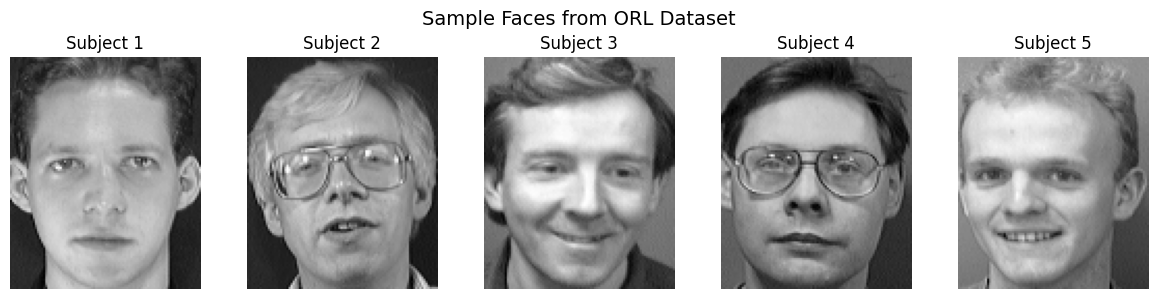

In [ ]:
# Quick sanity-check: display 5 sample faces
fig, axes = plt.subplots(1, 5, figsize=(12, 3)) # saf w 5 swr gnbo
for i, ax in enumerate(axes):# e3rd kol sora f cell
    img_path = os.path.join(DATASET_PATH, f's{i+1}', '1.pgm') # kol sha5s f folder w bngeeb awel sora l kol sha5s
    img = Image.open(img_path).convert('L')# eft7 sora w t7wlha l grayscale
    #grayscale 5alfya byda w ydi 3leha luminance
    ax.imshow(np.array(img), cmap='gray') # y7wl el sora l aarray of arkam
    ax.set_title(f'Subject {i+1}')# by7ot 3nwan fo2 el swr
    ax.axis('off')
plt.suptitle('Sample Faces from ORL Dataset', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Generate Data Matrix D and Label Vector y

In [ ]:
D = np.zeros((N_TOTAL, FLAT_SIZE), dtype=np.float64)   # 400 × 10304 ---------- gdwl fady esmo D 
y = np.zeros(N_TOTAL, dtype=int) # gdwl so8ayr --- 400 rkm kol rkm esm sha5s 

row = 0 # 3dada
for subject in range(1, N_SUBJECTS + 1):#hnlf 3la 3dd el ash5as
    for img_idx in range(1, N_PER_SUBJ + 1): #hnlf 3la kol sora
        img_path = os.path.join(DATASET_PATH, f's{subject}', f'{img_idx}.pgm') # bygeeb msar el sora 
        img = np.array(Image.open(img_path).convert('L'), dtype=np.float64)
        D[row] = img.flatten()          # row vector of 10304 values
        y[row] = subject                # label 1…40
        row += 1

print(f'D shape : {D.shape}  (expected 400 × 10304)')
print(f'y shape : {y.shape}  — unique labels: {np.unique(y)[[0,-1]]}')

D shape : (400, 10304)  (expected 400 × 10304)
y shape : (400,)  — unique labels: [ 1 40]


## 3. Split into Training and Test Sets (odd / even rows)

In [22]:
# Rows are 0-indexed; "odd rows" → index 0,2,4,… (images 1,3,5,7,9 per subject)
# "even rows" → index 1,3,5,… (images 2,4,6,8,10 per subject)
train_idx = np.arange(0, N_TOTAL, 2)   # 200 rows
test_idx  = np.arange(1, N_TOTAL, 2)   # 200 rows

X_train, y_train = D[train_idx], y[train_idx]
X_test,  y_test  = D[test_idx],  y[test_idx]

print(f'Training set : {X_train.shape}  — {len(np.unique(y_train))} subjects × 5 images')
print(f'Test set     : {X_test.shape}   — {len(np.unique(y_test))} subjects × 5 images')

Training set : (200, 10304)  — 40 subjects × 5 images
Test set     : (200, 10304)   — 40 subjects × 5 images


## 4. PCA Classification

Following Algorithm 7.1 from the assignment.

In [23]:
def pca(X_train, alpha):
    """
    Compute PCA projection matrix U_r that retains `alpha` fraction of variance.
    Returns: U_r (10304 × r), mean vector mu, and r.
    """
    n = X_train.shape[0]

    # Step 1: compute mean
    mu = X_train.mean(axis=0)                         # (10304,)

    # Step 2: centre data
    Z = X_train - mu                                   # (n × 10304)

    # Step 3: covariance (use ZZ^T trick for n << d)
    # Σ = (1/n) Z^T Z  but we compute via surrogate: C = (1/n) Z Z^T
    C = (1 / n) * Z @ Z.T                              # (n × n)

    # Step 4-5: eigendecomposition of surrogate
    eigvals, eigvecs_small = np.linalg.eigh(C)         # (n,), (n × n)
    # Sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs_small = eigvecs_small[:, idx]

    # Map back to original space: U = Z^T v  (normalised)
    U = Z.T @ eigvecs_small                            # (10304 × n)
    norms = np.linalg.norm(U, axis=0, keepdims=True)
    norms[norms == 0] = 1
    U = U / norms                                      # (10304 × n)

    # Keep only positive eigenvalues
    pos_mask = eigvals > 1e-10
    eigvals  = eigvals[pos_mask]
    U        = U[:, pos_mask]

    # Step 6-7: choose smallest r such that f(r) >= alpha
    cumvar = np.cumsum(eigvals) / eigvals.sum()
    r = int(np.searchsorted(cumvar, alpha)) + 1

    U_r = U[:, :r]   # (10304 × r)
    return U_r, mu, r


def project(X, U_r, mu):
    """Project data onto PCA subspace."""
    return (X - mu) @ U_r   # (n × r)


alphas = [0.80, 0.85, 0.90, 0.95]
pca_results = {}

print(f"{'Alpha':>6}  {'r (components)':>14}  {'Accuracy':>9}")
print('-' * 36)

for alpha in alphas:
    U_r, mu, r = pca(X_train, alpha)
    A_train = project(X_train, U_r, mu)
    A_test  = project(X_test,  U_r, mu)

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(A_train, y_train)
    acc = accuracy_score(y_test, knn.predict(A_test))

    pca_results[alpha] = {'r': r, 'accuracy': acc,
                          'U_r': U_r, 'mu': mu,
                          'A_train': A_train, 'A_test': A_test}
    print(f'{alpha:>6.2f}  {r:>14d}  {acc:>8.2%}')

 Alpha  r (components)   Accuracy
------------------------------------
  0.80              36    95.00%
  0.85              51    95.00%
  0.90              76    94.00%
  0.95             115    94.00%


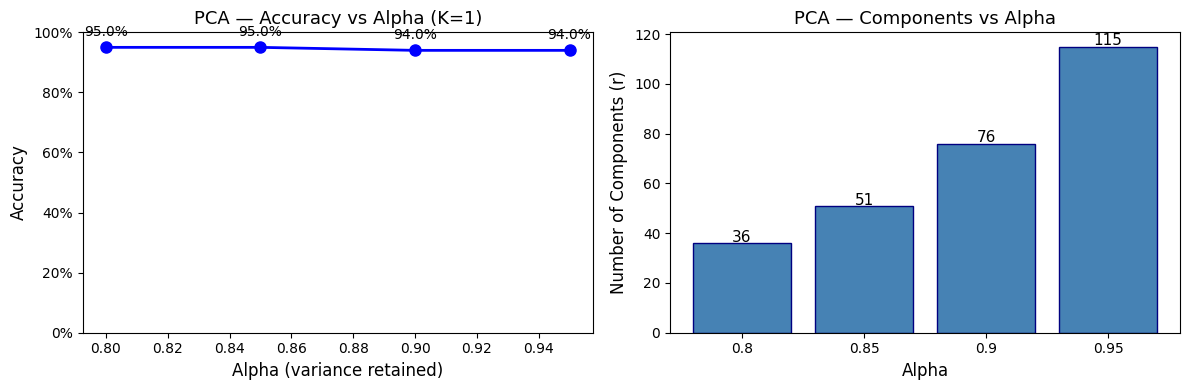


Observation: Higher alpha → more components retained → generally higher accuracy.
Diminishing returns: jump from 0.80→0.90 is large; 0.90→0.95 is smaller.


In [24]:
# Plot PCA accuracy vs alpha
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

accs = [pca_results[a]['accuracy'] for a in alphas]
rs   = [pca_results[a]['r']        for a in alphas]

axes[0].plot(alphas, accs, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Alpha (variance retained)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('PCA — Accuracy vs Alpha (K=1)', fontsize=13)
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
for a, acc in zip(alphas, accs):
    axes[0].annotate(f'{acc:.1%}', (a, acc), textcoords='offset points', xytext=(0,8), ha='center')

axes[1].bar([str(a) for a in alphas], rs, color='steelblue', edgecolor='navy')
axes[1].set_xlabel('Alpha', fontsize=12)
axes[1].set_ylabel('Number of Components (r)', fontsize=12)
axes[1].set_title('PCA — Components vs Alpha', fontsize=13)
for i, r in enumerate(rs):
    axes[1].text(i, r + 0.5, str(r), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('pca_accuracy_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation: Higher alpha → more components retained → generally higher accuracy.')
print('Diminishing returns: jump from 0.80→0.90 is large; 0.90→0.95 is smaller.')

###  Relation between alpha and accuracy

As **alpha increases**, more principal components are retained, meaning more of the original variance is preserved in the projection. This generally leads to **higher classification accuracy** because the projected representation is richer. However, there are diminishing returns: very high alpha (e.g., 0.99) may not improve accuracy much while drastically increasing dimensionality and computation time.

## 5. Multiclass LDA Classification

In [ ]:

# FAST Multiclass LDA via PCA --> LDA pipeline (Fisherfaces approach)
#
# WHY: Direct LDA on 10304-d space requires building 10304×10304 matrices
#      (~800 MB each) and inverting Sw — extremely slow & memory-heavy.
#
# FIX: First reduce to n-C dimensions with PCA (keeps all discriminative
#      info since rank(Sw) ≤ n-C), then run LDA in that small space.
#      This is the standard Fisherfaces method and runs in seconds.


def fast_multiclass_lda(X_train, y_train, n_lda_components=39):
    """
    PCA → LDA pipeline (Fisherfaces).
    Step 1: PCA to reduce from d=10304 to n-C dimensions (removes null space of Sw).
    Step 2: LDA in the reduced PCA space.
    Returns combined projection matrix W (d × n_lda_components) and mean.
    """
    n, d   = X_train.shape          # 200, 10304
    classes = np.unique(y_train)
    C       = len(classes)           # 40
    mu      = X_train.mean(axis=0)  # overall mean (d,)

    # ── Step 1: PCA — reduce to (n - C) = 160 dimensions 
    
    pca_dims = n - C                 # 160  (removes Sw null space)
    Z   = X_train - mu              # centre  (n × d)
    # Use surrogate covariance trick: eigen of (n×n) matrix instead of (d×d)
    Cov = (1 / n) * (Z @ Z.T)      # (n × n)
    eigvals_p, eigvecs_p = np.linalg.eigh(Cov)
    idx_p = np.argsort(eigvals_p)[::-1]
    eigvecs_p = eigvecs_p[:, idx_p[:pca_dims]]      # (n × pca_dims)
    W_pca = Z.T @ eigvecs_p                         # (d × pca_dims)
    norms = np.linalg.norm(W_pca, axis=0, keepdims=True)
    norms[norms == 0] = 1
    W_pca = W_pca / norms                           # normalise columns

    # Project training data into PCA space
    X_pca = Z @ W_pca               # (n × pca_dims)

    # ── Step 2: LDA in PCA space — matrices are now pca_dims × pca_dims ────
    p    = pca_dims
    mu_p = X_pca.mean(axis=0)       # overall mean in PCA space

    Sb = np.zeros((p, p))
    Sw = np.zeros((p, p))
    for k in classes:
        Xk   = X_pca[y_train == k]
        mu_k = Xk.mean(axis=0)
        diff = (mu_k - mu_p).reshape(-1, 1)
        Sb  += len(Xk) * (diff @ diff.T)
        Zk   = Xk - mu_k
        Sw  += Zk.T @ Zk

    # Solve Sw^{-1} Sb — Sw is now (160×160), trivially invertible
    Sw_inv = np.linalg.pinv(Sw)
    M      = Sw_inv @ Sb
    eigvals_l, eigvecs_l = np.linalg.eig(M)
    eigvals_l = eigvals_l.real
    eigvecs_l = eigvecs_l.real
    idx_l     = np.argsort(eigvals_l)[::-1]
    n_lda_components = min(n_lda_components, C - 1)   # ≤ 39
    W_lda = eigvecs_l[:, idx_l[:n_lda_components]]    # (pca_dims × 39)

    # ── Combined projection: original space → 39 LDA dims ───────────────────
    W_combined = W_pca @ W_lda      # (d × 39)
    return W_combined, mu


import time
print('Training LDA (fast PCA→LDA pipeline)…')
t0 = time.time()
U_lda, mu_lda = fast_multiclass_lda(X_train, y_train, n_lda_components=39)
print(f'Done in {time.time()-t0:.1f}s  |  projection matrix: {U_lda.shape}  (expected 10304 × 39)')

# Project
B_train = (X_train - mu_lda) @ U_lda   # (200 × 39)
B_test  = (X_test  - mu_lda) @ U_lda   # (200 × 39)

knn_lda = KNeighborsClassifier(n_neighbors=1)
knn_lda.fit(B_train, y_train)
lda_acc = accuracy_score(y_test, knn_lda.predict(B_test))

print(f'\nLDA Accuracy (K=1): {lda_acc:.2%}')

Training LDA (fast PCA→LDA pipeline)…
Done in 0.1s  |  projection matrix: (10304, 39)  (expected 10304 × 39)

LDA Accuracy (K=1): 93.00%


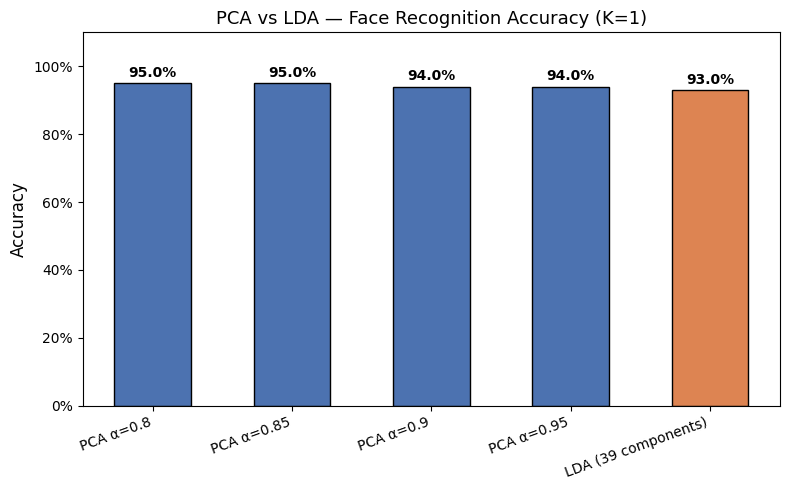

In [26]:
# Compare PCA vs LDA
fig, ax = plt.subplots(figsize=(8, 5))

labels  = [f'PCA α={a}' for a in alphas] + ['LDA (39 components)']
accs_all = accs + [lda_acc]
colors  = ['#4C72B0'] * len(alphas) + ['#DD8452']

bars = ax.bar(labels, accs_all, color=colors, edgecolor='black', width=0.55)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('PCA vs LDA — Face Recognition Accuracy (K=1)', fontsize=13)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
for bar, acc in zip(bars, accs_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('pca_vs_lda.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Classifier Tuning — K-NN with K = 1, 3, 5, 7

In [27]:
K_VALUES = [1, 3, 5, 7]
# Tie-breaking strategy: distance-weighted voting (weights='distance')

tuning_results = {'PCA': {a: [] for a in alphas}, 'LDA': []}

print(f"{'Method':>20}  " + '  '.join(f'K={k:>1}' for k in K_VALUES))
print('-' * 52)

for alpha in alphas:
    row_str = f'PCA α={alpha}              '
    res_row = []
    for k in K_VALUES:
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        knn.fit(pca_results[alpha]['A_train'], y_train)
        acc = accuracy_score(y_test, knn.predict(pca_results[alpha]['A_test']))
        tuning_results['PCA'][alpha].append(acc)
        res_row.append(f'{acc:.2%}')
    print(f'PCA α={alpha}              ' + '   '.join(res_row))

row_lda = []
for k in K_VALUES:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(B_train, y_train)
    acc = accuracy_score(y_test, knn.predict(B_test))
    tuning_results['LDA'].append(acc)
    row_lda.append(f'{acc:.2%}')
print(f'LDA (39 comp)               ' + '   '.join(row_lda))

              Method  K=1  K=3  K=5  K=7
----------------------------------------------------
PCA α=0.8              95.00%   93.00%   93.00%   91.00%
PCA α=0.85              95.00%   93.00%   91.50%   87.50%
PCA α=0.9              94.00%   93.00%   90.50%   87.50%
PCA α=0.95              94.00%   92.00%   89.50%   85.50%
LDA (39 comp)               93.00%   92.50%   92.50%   92.50%


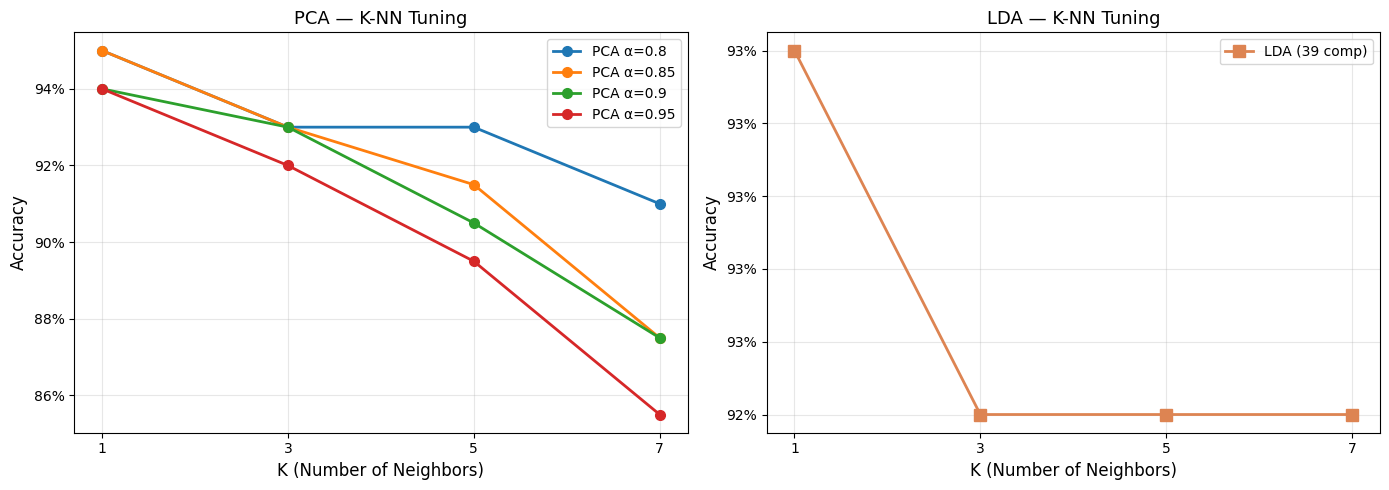

In [28]:
# Plot K vs Accuracy for all methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha in alphas:
    axes[0].plot(K_VALUES, tuning_results['PCA'][alpha], 'o-',
                 label=f'PCA α={alpha}', linewidth=2, markersize=7)
axes[0].set_xlabel('K (Number of Neighbors)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('PCA — K-NN Tuning', fontsize=13)
axes[0].set_xticks(K_VALUES)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_VALUES, tuning_results['LDA'], 's-', color='#DD8452',
             label='LDA (39 comp)', linewidth=2, markersize=8)
axes[1].set_xlabel('K (Number of Neighbors)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('LDA — K-NN Tuning', fontsize=13)
axes[1].set_xticks(K_VALUES)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. BONUS A — Faces vs Non-Faces 

We add a 41st class: **non-face images** resized to 92×112.

### 7-i. Prepare Non-Face Images

We use scikit-image's built-in image collection (coins, camera, etc.) and also download from a free source. You can replace `NON_FACE_PATH` with any folder of JPEG/PNG images.

Non-face samples collected: 15


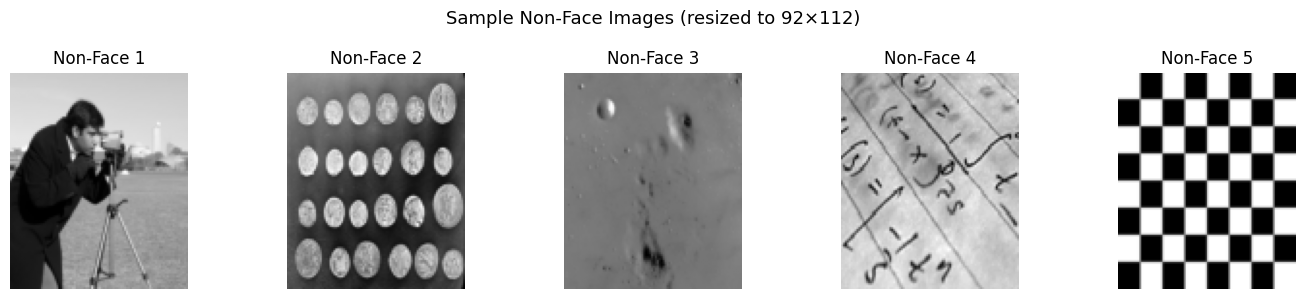

In [29]:
from skimage import data as skdata
from skimage.transform import resize as sk_resize
from skimage.color import rgb2gray

def to_gray(img):
    """Safely convert any skimage image to 2D float grayscale."""
    if img.ndim == 2:
        return img.astype(np.float64)           # already grayscale / binary
    elif img.ndim == 3 and img.shape[2] == 3:
        return rgb2gray(img)                    # RGB  → gray
    elif img.ndim == 3 and img.shape[2] == 4:
        return rgb2gray(img[:, :, :3])          # RGBA → gray
    else:
        return img[:, :, 0].astype(np.float64)  # fallback

# ── Collect non-face images (skimage built-ins) ──────────────────────────────
_candidates = [
    ('camera',       skdata.camera),
    ('coins',        skdata.coins),
    ('moon',         skdata.moon),
    ('text',         skdata.text),
    ('checkerboard', skdata.checkerboard),
    ('brick',        skdata.brick),
    ('grass',        skdata.grass),
    ('gravel',       skdata.gravel),
    ('page',         skdata.page),
    ('astronaut',    skdata.astronaut),
    ('coffee',       skdata.coffee),
    ('chelsea',      skdata.chelsea),
    ('ihc',          skdata.immunohistochemistry),
    ('rocket',       skdata.rocket),
    ('horse',        skdata.horse),
]

non_face_images_raw = []
for name, loader in _candidates:
    try:
        img = loader()
        gray = to_gray(img)
        non_face_images_raw.append(gray)
    except Exception as e:
        print(f'Skipping {name}: {e}')

def preprocess_nonface(gray_array):
    resized = sk_resize(gray_array, (IMG_H, IMG_W),
                        anti_aliasing=True, preserve_range=False)
    return (resized * 255).astype(np.float64).flatten()

non_face_vectors = np.array([preprocess_nonface(img) for img in non_face_images_raw])

print(f'Non-face samples collected: {len(non_face_vectors)}')

# Show sample non-face images
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(non_face_vectors[i].reshape(IMG_H, IMG_W), cmap='gray')
    ax.set_title(f'Non-Face {i+1}')
    ax.axis('off')
plt.suptitle('Sample Non-Face Images (resized to 92×112)', fontsize=13)
plt.tight_layout()
plt.show()

### 7-ii. Binary Classification: Faces vs Non-Faces

In [30]:
def faces_vs_nonfaces_experiment(n_nonfaces, face_train=X_train, face_test=X_test,
                                  y_face_train=y_train, y_face_test=y_test,
                                  all_nonfaces=non_face_vectors):
    """
    Binary classification: label 0 = non-face, label 1 = face.
    Uses LDA (1 discriminant vector for binary problem).
    n_nonfaces: number of non-face samples to include.
    """
    # We need at least n_nonfaces available; repeat/tile if needed
    if n_nonfaces > len(all_nonfaces):
        repeats = int(np.ceil(n_nonfaces / len(all_nonfaces)))
        nf = np.tile(all_nonfaces, (repeats, 1))[:n_nonfaces]
    else:
        nf = all_nonfaces[:n_nonfaces]

    # Split non-faces 50/50 train/test
    nf_train = nf[:n_nonfaces // 2]
    nf_test  = nf[n_nonfaces // 2:]

    # Binary labels: faces=1, non-faces=0
    y_face_tr_bin = np.ones(len(face_train), dtype=int)
    y_face_te_bin = np.ones(len(face_test),  dtype=int)
    y_nf_tr_bin   = np.zeros(len(nf_train),  dtype=int)
    y_nf_te_bin   = np.zeros(len(nf_test),   dtype=int)

    X_tr = np.vstack([face_train, nf_train])
    y_tr = np.concatenate([y_face_tr_bin, y_nf_tr_bin])
    X_te = np.vstack([face_test,  nf_test])
    y_te = np.concatenate([y_face_te_bin, y_nf_te_bin])

    # Fast binary LDA via PCA→LDA (avoids building 10304×10304 matrices)
    mu_all = X_tr.mean(axis=0)
    n_tr   = X_tr.shape[0]
    Z_tr   = X_tr - mu_all
    # PCA step: reduce to n_tr-1 dims using surrogate trick
    pca_d  = min(n_tr - 1, 199)
    Cov_s  = (1 / n_tr) * (Z_tr @ Z_tr.T)
    ev_p, evec_p = np.linalg.eigh(Cov_s)
    idx_p  = np.argsort(ev_p)[::-1]
    evec_p = evec_p[:, idx_p[:pca_d]]
    W_pca  = Z_tr.T @ evec_p
    nm     = np.linalg.norm(W_pca, axis=0, keepdims=True); nm[nm==0]=1
    W_pca  = W_pca / nm
    X_tr_p = Z_tr @ W_pca
    # LDA in PCA space (pca_d × pca_d — small!)
    mu_p   = X_tr_p.mean(axis=0)
    Sb_p   = np.zeros((pca_d, pca_d))
    Sw_p   = np.zeros((pca_d, pca_d))
    for k in [0, 1]:
        Xk   = X_tr_p[y_tr == k]
        mu_k = Xk.mean(axis=0)
        diff = (mu_k - mu_p).reshape(-1, 1)
        Sb_p += len(Xk) * (diff @ diff.T)
        Sw_p += (Xk - mu_k).T @ (Xk - mu_k)
    M      = np.linalg.pinv(Sw_p) @ Sb_p
    ev_l, evec_l = np.linalg.eig(M)
    ev_l = ev_l.real; evec_l = evec_l.real
    w_lda  = evec_l[:, np.argsort(ev_l)[::-1][:1]]   # (pca_d × 1)
    U_bin  = W_pca @ w_lda                            # (d × 1)

    proj_tr = (X_tr - mu_all) @ U_bin
    proj_te = (X_te - mu_all) @ U_bin

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(proj_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(proj_te))
    return acc, y_te, knn.predict(proj_te), proj_te, mu_all, U_bin


# ── Run with baseline number of non-faces ──────────────────────────────────
n_nonfaces_base = 200   # same as face test count for balance
acc_bin, y_te_b, y_pred_b, proj_b, mu_b, U_b = faces_vs_nonfaces_experiment(n_nonfaces_base)
print(f'Binary (Faces vs Non-Faces) LDA Accuracy: {acc_bin:.2%}')

Binary (Faces vs Non-Faces) LDA Accuracy: 100.00%


### 7-iii Show Success and Failure Cases

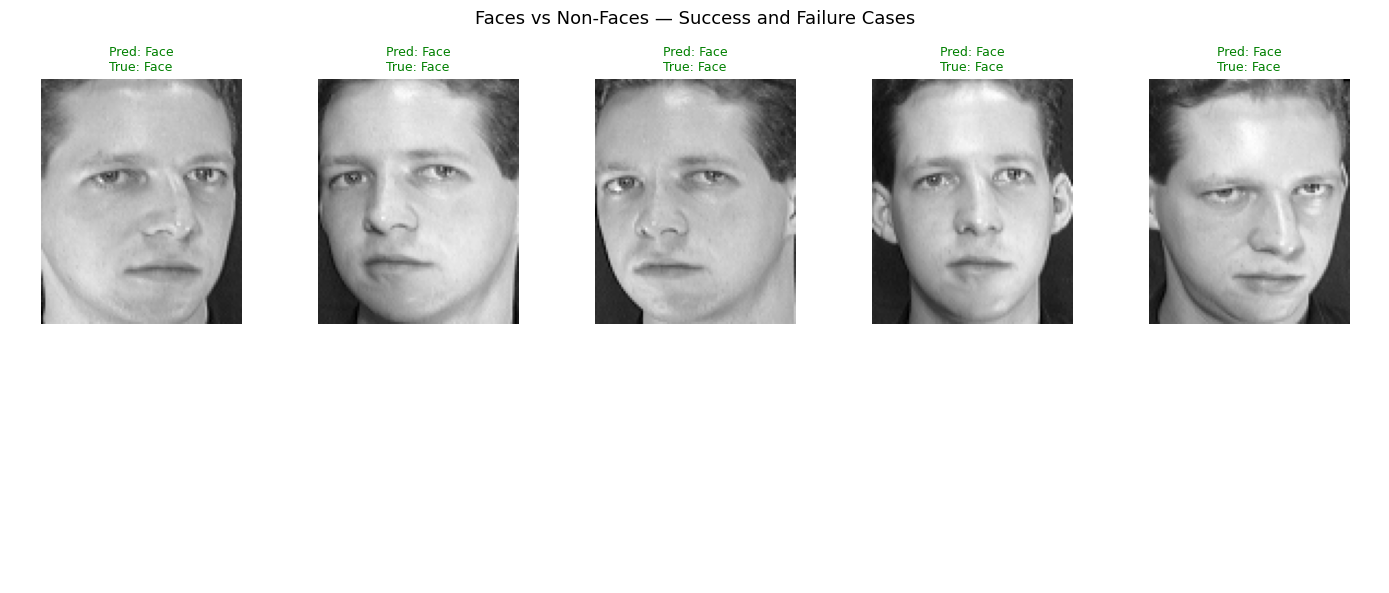

Total correct : 300
Total wrong   : 0


In [31]:
# Rebuild test set for visualization
n_nf = n_nonfaces_base
nf_test_imgs = non_face_vectors[n_nf//2:n_nf]
face_test_imgs = X_test

all_test_imgs = np.vstack([face_test_imgs, nf_test_imgs])
true_labels   = np.concatenate([np.ones(len(face_test_imgs)),
                                 np.zeros(len(nf_test_imgs))])

correct_idx = np.where(y_pred_b == y_te_b)[0]
wrong_idx   = np.where(y_pred_b != y_te_b)[0]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
label_map = {1: 'Face', 0: 'Non-Face'}

for i, ax in enumerate(axes[0]):
    if i < len(correct_idx):
        idx = correct_idx[i]
        ax.imshow(all_test_imgs[idx].reshape(IMG_H, IMG_W), cmap='gray')
        ax.set_title(f'Pred: {label_map[y_pred_b[idx]]}\nTrue: {label_map[y_te_b[idx]]}',
                     fontsize=9, color='green')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    if i < len(wrong_idx):
        idx = wrong_idx[i]
        ax.imshow(all_test_imgs[idx].reshape(IMG_H, IMG_W), cmap='gray')
        ax.set_title(f'Pred: {label_map[y_pred_b[idx]]}\nTrue: {label_map[y_te_b[idx]]}',
                     fontsize=9, color='red')
    ax.axis('off')

axes[0][0].set_ylabel('Success Cases', fontsize=11)
axes[1][0].set_ylabel('Failure Cases', fontsize=11)
plt.suptitle('Faces vs Non-Faces — Success and Failure Cases', fontsize=13)
plt.tight_layout()
plt.savefig('success_failure_cases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total correct : {len(correct_idx)}')
print(f'Total wrong   : {len(wrong_idx)}')

### 7a — LDA Components for Binary Problem

For a **binary classification** (faces vs non-faces), LDA can find at most **C − 1 = 1** discriminant direction. So we use **1 dominant eigenvector**.

### 7a — Accuracy vs Number of Non-Face Images (fixing face count)

  Non-faces:    10 → Accuracy: 99.51%
  Non-faces:    20 → Accuracy: 97.62%
  Non-faces:    50 → Accuracy: 100.00%
  Non-faces:   100 → Accuracy: 100.00%
  Non-faces:   200 → Accuracy: 100.00%
  Non-faces:   400 → Accuracy: 100.00%
  Non-faces:   800 → Accuracy: 100.00%
  Non-faces:  2000 → Accuracy: 100.00%


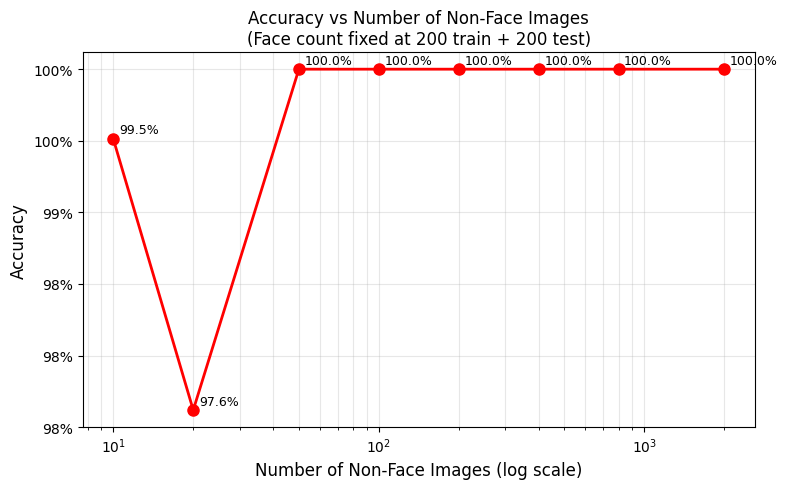

In [32]:
nonface_counts = [10, 20, 50, 100, 200, 400, 800, 2000]
acc_vs_nonfaces = []

for n in nonface_counts:
    acc, *_ = faces_vs_nonfaces_experiment(n)
    acc_vs_nonfaces.append(acc)
    print(f'  Non-faces: {n:>5} → Accuracy: {acc:.2%}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(nonface_counts, acc_vs_nonfaces, 'ro-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Non-Face Images (log scale)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs Number of Non-Face Images\n(Face count fixed at 200 train + 200 test)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.grid(True, which='both', alpha=0.3)
for n, a in zip(nonface_counts, acc_vs_nonfaces):
    ax.annotate(f'{a:.1%}', (n, a), textcoords='offset points', xytext=(4, 4), fontsize=9)
plt.tight_layout()
plt.savefig('accuracy_vs_nonfaces.png', dpi=150, bbox_inches='tight')
plt.show()

### 7a — Critique of Accuracy for Large Non-Face Counts

When the number of non-face images grows very large compared to face images, the **class imbalance** causes accuracy to become a **misleading metric**:

- A trivial classifier that **always predicts "non-face"** can achieve very high accuracy (e.g., if 95% of test images are non-faces, blind prediction gives 95% accuracy).
- Better metrics for imbalanced problems: **F1-score**, **precision/recall**, **AUC-ROC**, or **balanced accuracy**.
- The LDA decision boundary is also biased toward the majority class, causing more face misclassifications.

---
## 7b. BONUS

In [33]:
# 70/30 split: 7 instances per subject for training, 3 for testing
train_70_idx = []
test_30_idx  = []

for subj in range(N_SUBJECTS):
    base = subj * N_PER_SUBJ
    train_70_idx.extend(range(base, base + 7))    # images 1-7
    test_30_idx.extend(range(base + 7, base + 10)) # images 8-10

X_tr70, y_tr70 = D[train_70_idx], y[train_70_idx]
X_te30, y_te30 = D[test_30_idx],  y[test_30_idx]

print(f'70% split — Train: {X_tr70.shape}, Test: {X_te30.shape}')

# ── PCA 70/30 ─────────────────────────────────────────────────────────────
print('\nPCA Results (70/30 split):')
pca_70_accs = []
for alpha in alphas:
    U_r70, mu70, r70 = pca(X_tr70, alpha)
    A_tr70 = project(X_tr70, U_r70, mu70)
    A_te30 = project(X_te30, U_r70, mu70)
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(A_tr70, y_tr70)
    acc70 = accuracy_score(y_te30, knn.predict(A_te30))
    pca_70_accs.append(acc70)
    print(f'  α={alpha}: r={r70}, Accuracy={acc70:.2%}')

# ── LDA 70/30 ─────────────────────────────────────────────────────────────
print('\nLDA (70/30 split):')
U_lda70, mu_lda70 = fast_multiclass_lda(X_tr70, y_tr70, n_lda_components=39)
B_tr70 = (X_tr70 - mu_lda70) @ U_lda70
B_te30 = (X_te30 - mu_lda70) @ U_lda70
knn_lda70 = KNeighborsClassifier(n_neighbors=1)
knn_lda70.fit(B_tr70, y_tr70)
lda_70_acc = accuracy_score(y_te30, knn_lda70.predict(B_te30))
print(f'  LDA Accuracy (K=1): {lda_70_acc:.2%}')

70% split — Train: (280, 10304), Test: (120, 10304)

PCA Results (70/30 split):
  α=0.8: r=39, Accuracy=95.83%
  α=0.85: r=57, Accuracy=96.67%
  α=0.9: r=89, Accuracy=96.67%
  α=0.95: r=145, Accuracy=95.00%

LDA (70/30 split):
  LDA Accuracy (K=1): 92.50%


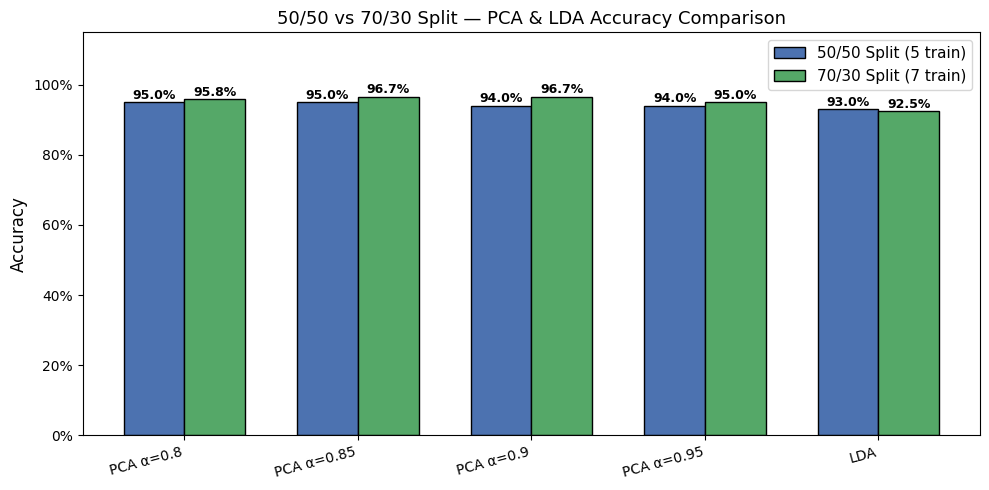


Conclusion: The 70/30 split (more training data) generally produces higher
accuracy because the model sees more variation per subject during training.


In [34]:
# Comparison: 50/50 vs 70/30 split
x = np.arange(len(alphas) + 1)
width = 0.35

split50_accs = accs + [lda_acc]
split70_accs = pca_70_accs + [lda_70_acc]
x_labels     = [f'PCA α={a}' for a in alphas] + ['LDA']

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, split50_accs, width, label='50/50 Split (5 train)', color='#4C72B0', edgecolor='black')
bars2 = ax.bar(x + width/2, split70_accs, width, label='70/30 Split (7 train)', color='#55A868', edgecolor='black')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('50/50 vs 70/30 Split — PCA & LDA Accuracy Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.legend(fontsize=11)

for bar, acc in zip(bars1, split50_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontsize=9, fontweight='bold')
for bar, acc in zip(bars2, split70_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('split_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nConclusion: The 70/30 split (more training data) generally produces higher')
print('accuracy because the model sees more variation per subject during training.')

---
## Summary Table

In [36]:
print('-'*60)
print('            FINAL RESULTS SUMMARY')
print('-'*60)
print(f'{"Method":<30} {"50/50 Split":>12} {"70/30 Split":>12}')
print('-'*60)
for i, alpha in enumerate(alphas):
    print(f'PCA α={alpha} (K=1)           {accs[i]:>11.2%} {pca_70_accs[i]:>12.2%}')
print(f'LDA 39 components (K=1)       {lda_acc:>11.2%} {lda_70_acc:>12.2%}')
print('-'*60)
print(f'Faces vs Non-Faces (LDA)      {acc_bin:>11.2%} {"—":>12}')
print('-'*60)

------------------------------------------------------------
            FINAL RESULTS SUMMARY
------------------------------------------------------------
Method                          50/50 Split  70/30 Split
------------------------------------------------------------
PCA α=0.8 (K=1)                95.00%       95.83%
PCA α=0.85 (K=1)                95.00%       96.67%
PCA α=0.9 (K=1)                94.00%       96.67%
PCA α=0.95 (K=1)                94.00%       95.00%
LDA 39 components (K=1)            93.00%       92.50%
------------------------------------------------------------
Faces vs Non-Faces (LDA)          100.00%            —
------------------------------------------------------------
